# Proyecto Pipeline Automatizado con Modelo Detector de IA sobre Código Vulnerable

## Descarga de Datasets y Normalización de Dataset

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn lime shap kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os, re, glob, warnings
from pathlib import Path
import joblib

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42

### Dataset Kaggle

[URL Dataset](https://www.kaggle.com/datasets/jiscecseaiml/vulnerability-fix-dataset)

In [3]:
!pip install -q kagglehub

In [4]:
import kagglehub

path = kagglehub.dataset_download('jiscecseaiml/vulnerability-fix-dataset')
print(path)

kaggle_dataset = pd.read_csv(f'{path}/vulnerability_fix_dataset.csv')

100%|██████████| 4.04M/4.04M [00:00<00:00, 44.9MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/jiscecseaiml/vulnerability-fix-dataset/versions/1


In [5]:
# Debug
kaggle_dataset.head()
kaggle_dataset.shape

(35000, 3)

### Dataset HuggingFace

[URL Dataset](https://huggingface.co/datasets/nuojohnchen/devign-processed)

In [6]:
!pip install -q datasets

In [7]:
from datasets import load_dataset

hf_dataset_raw = load_dataset('nuojohnchen/devign-processed')

hf_dataset = hf_dataset_raw['train'].to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


train.jsonl:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

valid.jsonl:   0%|          | 0.00/4.11M [00:00<?, ?B/s]

dev.jsonl:   0%|          | 0.00/4.12M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/4.16M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/21854 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5464 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2732 [00:00<?, ? examples/s]

In [8]:
# Debug
hf_dataset.head()
hf_dataset.shape

(21854, 3)

### Dataset Unificado

In [9]:
rows = []

# Kaggle
for _, row in kaggle_dataset.iterrows():
    rows.append({
        "function": row["vulnerable_code"],
        "is_vulnerable": True
    })

    rows.append({
        "function": row["fixed_code"],
        "is_vulnerable": False
    })

# Hugging Face
for _, row in hf_dataset.iterrows():
    rows.append({
        "function": row["func1"],
        "is_vulnerable": row["label"] == 0
    })

full_dataset = pd.DataFrame(rows)

In [10]:
# Debug
full_dataset.shape

full_dataset.value_counts('is_vulnerable')

,count
is_vulnerable,
True,46836
False,45018


## Partición train/test

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    full_dataset["function"], full_dataset["is_vulnerable"],
    test_size=0.25, random_state=RANDOM_STATE, stratify=full_dataset["is_vulnerable"]
)

## Entrenamiento del Modelo

### Sanitización

### Features de seguridad (SAST)

Escribimos el modulo `pipeline/security_features.py` para que el modelo serializado lo referencie por esa ruta y el pipeline CI/CD pueda deserializarlo.

In [12]:
import os, sys, pathlib

_SECURITY_FEATURES_SRC = "import re\n\nimport numpy as np\nfrom scipy import sparse\nfrom sklearn.base import BaseEstimator, TransformerMixin\n\n# Se\u00f1ales de c\u00f3digo VULNERABLE: llamadas peligrosas, SQL sin parametrizar,\n# fuentes de entrada sin sanitizar. Cada patr\u00f3n es una feature binaria.\nVULN_PATTERNS = [\n  r'\\beval\\s*\\(',\n  r'\\bexec\\s*\\(',\n  r'\\bos\\.system\\s*\\(',\n  r'\\bos\\.popen\\s*\\(',\n  r'subprocess\\.\\w+\\([^)]*shell\\s*=\\s*True',\n  r'\\bsystem\\s*\\(',\n  r'\\b(pickle\\.loads?|cPickle\\.loads?)\\s*\\(',\n  r'\\byaml\\.load\\s*\\(',\n  r'\\b(md5|sha1)\\s*\\(',\n  r'\\b(gets|strcpy|strcat|sprintf|memcpy)\\s*\\(',\n  r'(SELECT|INSERT|UPDATE|DELETE)\\b[^;\\n]*(\\+|\\.format\\s*\\(|f[\"\\'])',\n  r'\\.innerHTML\\s*=',\n  r'document\\.write\\s*\\(',\n  r'(\\.\\./|\\.\\.\\\\)',\n  r'os\\.path\\.join\\s*\\(',\n  r'(password|passwd|secret|api_?key|token)\\s*=\\s*[\"\\'][^\"\\']+[\"\\']',\n]\n\n# Se\u00f1ales de c\u00f3digo SEGURO: parametrizaci\u00f3n, hashing fuerte, sanitizaci\u00f3n,\n# normalizaci\u00f3n de rutas, formas seguras de subprocess.\nSAFE_PATTERNS = [\n  r'execute\\s*\\([^)]*,\\s*[\\(\\[]',\n  r'\\?\\s*[,\\)]',\n  r'\\b(bcrypt|scrypt|argon2|pbkdf2)\\b',\n  r'\\b(escape|sanitize|htmlspecialchars|quote)\\s*\\(',\n  r'os\\.path\\.basename\\s*\\(',\n  r'\\b(realpath|abspath)\\s*\\(',\n  r'(preparedstatement|preparestatement|setstring)',\n  r'subprocess\\.(run|call|Popen)\\s*\\(\\s*\\[',\n  r'%s[\"\\']?\\s*,',\n]\n\n_VULN_RE = [re.compile(p, re.IGNORECASE) for p in VULN_PATTERNS]\n_SAFE_RE = [re.compile(p, re.IGNORECASE) for p in SAFE_PATTERNS]\n\n\ndef _nesting_depth(code):\n  \"\"\"Profundidad estructural (proxy de AST depth) agn\u00f3stica al lenguaje.\n\n  Combina el anidamiento m\u00e1ximo de par\u00e9ntesis/llaves/corchetes (C, Java, JS)\n  con la profundidad por indentaci\u00f3n (Python), tomando el m\u00e1ximo.\n  \"\"\"\n  depth = max_depth = 0\n  for ch in code:\n    if ch in '([{':\n      depth += 1\n      if depth > max_depth:\n        max_depth = depth\n    elif ch in ')]}':\n      depth = max(0, depth - 1)\n\n  indent_depth = 0\n  for line in code.split('\\n'):\n    stripped = line.lstrip(' ')\n    if stripped:\n      indent_depth = max(indent_depth, (len(line) - len(stripped)) // 4)\n\n  return max(max_depth, indent_depth)\n\n\nclass SecurityFeatures(BaseEstimator, TransformerMixin):\n  \"\"\"Extrae features de seguridad interpretables de cada fragmento de c\u00f3digo.\n\n  Devuelve una matriz dispersa con una columna por patr\u00f3n vulnerable, una por\n  patr\u00f3n seguro, la longitud normalizada y la profundidad estructural\n  (proxy de AST depth). La longitud y la profundidad son features expl\u00edcitas\n  para que esas se\u00f1ales no queden absorbidas por el intercepto del modelo.\n  \"\"\"\n\n  def __init__(self, scale=1.0):\n    self.scale = scale\n\n  def fit(self, X, y=None):\n    return self\n\n  def transform(self, X):\n    rows = []\n    for code in X:\n      code = code if isinstance(code, str) else str(code)\n      feats = [self.scale if r.search(code) else 0.0 for r in _VULN_RE]\n      feats += [self.scale if r.search(code) else 0.0 for r in _SAFE_RE]\n      feats.append(min(len(code) / 1000.0, 5.0))\n      feats.append(min(_nesting_depth(code) / 3.0, 5.0))\n      rows.append(feats)\n\n    return sparse.csr_matrix(np.array(rows, dtype=np.float64))\n"

pathlib.Path("pipeline").mkdir(exist_ok=True)
pathlib.Path("pipeline/__init__.py").touch()
with open("pipeline/security_features.py", "w") as _f:
    _f.write(_SECURITY_FEATURES_SRC)

sys.path.insert(0, os.getcwd())
from pipeline.security_features import SecurityFeatures


In [13]:
TOKEN_PATTERN = r"(?u)\b\w+\b|==|!=|<=|>=|&&|\|\||[{}()\[\];=+\-*/<>.'\"]"

vectorizer = FeatureUnion([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        token_pattern=TOKEN_PATTERN,
        ngram_range=(1, 2),
        min_df=1,
        max_features=20000,
        sublinear_tf=True,
    )),
    ("sec", SecurityFeatures(scale=3.0)),
])

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [14]:
analyzer = vectorizer.transformer_list[0][1].build_analyzer()

analyzer(X_train.iloc[1])


['string',
 'userinput',
 '=',
 '"',
 "'",
 ';',
 'drop',
 'table',
 'users',
 ';',
 '-',
 '-',
 '"',
 ';',
 '/',
 '/',
 'create',
 'a',
 'preparedstatement',
 'with',
 'parameterized',
 'query',
 'string',
 'query',
 '=',
 '"',
 'select',
 '*',
 'from',
 'users',
 'where',
 'username',
 '=',
 '"',
 ';',
 'preparedstatement',
 'statement',
 '=',
 'connection',
 '.',
 'preparestatement',
 '(',
 'query',
 ')',
 ';',
 'statement',
 '.',
 'setstring',
 '(',
 '1',
 'userinput',
 ')',
 ';',
 '/',
 '/',
 'execute',
 'the',
 'query',
 'using',
 'the',
 'preparedstatement',
 'resultset',
 'resultset',
 '=',
 'statement',
 '.',
 'executequery',
 '(',
 ')',
 ';',
 '/',
 '/',
 'process',
 'the',
 'resultset',
 'as',
 'needed',
 'string userinput',
 'userinput =',
 '= "',
 '" \'',
 "' ;",
 '; drop',
 'drop table',
 'table users',
 'users ;',
 '; -',
 '- -',
 '- "',
 '" ;',
 '; /',
 '/ /',
 '/ create',
 'create a',
 'a preparedstatement',
 'preparedstatement with',
 'with parameterized',
 'parameter

### Entrenamiento

In [15]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    C=1.0,
    random_state=RANDOM_STATE,
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## Evaluación del Modelo

Accuracy: 0.9101202

              precision    recall  f1-score   support

       False     0.9136    0.9019    0.9077     11255
        True     0.9069    0.9180    0.9124     11709

    accuracy                         0.9101     22964
   macro avg     0.9102    0.9100    0.9101     22964
weighted avg     0.9102    0.9101    0.9101     22964



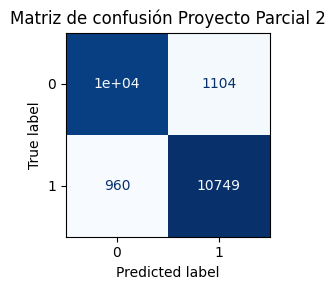

In [16]:
y_pred = model.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.7f}")
print()
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(4, 3))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de confusión Proyecto Parcial 2")
plt.tight_layout()
plt.show()

## Descarga del Modelo

In [17]:
joblib.dump({
    "vectorizer": vectorizer,
    "model": model
}, "vulnerability_detector.pkl")

['vulnerability_detector.pkl']

## Prueba de código individual

In [18]:
# Carga de modelo
import joblib

saved = joblib.load("vulnerability_detector.pkl")

vectorizer = saved["vectorizer"]
model = saved["model"]

In [19]:
code = """
cursor.execute(
    "SELECT * FROM users WHERE username='" + user + "'"
)
"""

X = vectorizer.transform([code])

prediction = model.predict(X)[0]
probability = model.predict_proba(X)[0]

print("Vulnerable:", prediction)
print("Probabilidades:", probability)

Vulnerable: True
Probabilidades: [0.00530388 0.99469612]
